In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

!apt-get install -y unrar

rar_path = '/content/drive/MyDrive/fairface_dataset.rar'

print("در حال استخراج فایل‌های rar...")
!unrar x "{rar_path}" /content/

print("استخراج با موفقیت انجام شد!")

Streaming output truncated to the last 5000 lines.
Extracting  /content/train/83570.jpg                                      94%  OK 
Extracting  /content/train/83571.jpg                                      94%  OK 
Extracting  /content/train/83572.jpg                                      94%  OK 
Extracting  /content/train/83573.jpg                                      94%  OK 
Extracting  /content/train/83574.jpg                                      94%  OK 
Extracting  /content/train/83575.jpg                                      94%  OK 
Extracting  /content/train/83576.jpg                                      94%  OK 
Extracting  /content/train/83577.jpg                                      94%  OK 
Extracting  /content/train/83578.jpg                                      94%  OK 
Extracting  /content/train/83579.jpg                                      94%  OK 
Extracting  /content/train/83

In [13]:
import os
import pandas as pd
import numpy as np
import copy
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from PIL import Image
import torch
from torch import nn
from torch import optim
from torch.utils.data import Dataset , DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [26]:
NUM_EPOCHS = 15
BATCH_SIZE = 64
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 2

In [5]:
class FairFaceDataset(Dataset):
    def __init__(self , csv_file , root , transform):
        self.df = pd.read_csv(csv_file)
        self.root = root
        self.transform = transform

        self.classes = sorted(self.df['race'].unique().tolist())
        self.index_to_race = {index : race for index , race in enumerate(self.classes)}
        self.race_to_index = {race : index for index , race in enumerate(self.classes)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        if torch.is_tensor(index):
            index = index.tolist()

        image_rel_path = self.df.iloc[index]['file']
        image_path = os.path.join(self.root , image_rel_path)
        image = Image.open(image_path).convert('RGB')

        race_name = self.df.iloc[index]['race']
        label = self.race_to_index[race_name]

        image = self.transform(image)

        return image , label

In [19]:
train_transform = transforms.Compose([transforms.Resize((56 , 56)) , transforms.RandomHorizontalFlip(p=0.5) , transforms.ToTensor()])
val_transform = transforms.Compose([transforms.Resize((56 , 56)) , transforms.ToTensor()])

In [20]:
train_dataset = FairFaceDataset('fairface-label-train.csv' , '.' , train_transform)
val_dataset = FairFaceDataset('fairface-label-val.csv' , '.' , val_transform)

In [21]:
train_dataloader = DataLoader(train_dataset , batch_size=BATCH_SIZE , shuffle=True, num_workers=NUM_WORKERS , pin_memory=True)
val_dataloader = DataLoader(val_dataset , batch_size=BATCH_SIZE , shuffle=False , num_workers=NUM_WORKERS , pin_memory=True)

ابعاد تنسور تصاویر: torch.Size([64, 3, 56, 56])
ابعاد تنسور لیبل‌ها: torch.Size([64])
لیبل چند نمونه اول: tensor([1, 2, 2, 6, 6])

--- اطلاعات بچ اعتبارسنجی ---
ابعاد تنسور تصاویر اعتبارسنجی: torch.Size([64, 3, 56, 56])


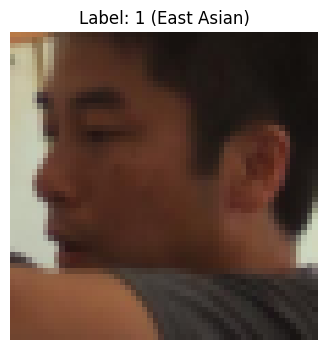

In [22]:
train_images, train_labels = next(iter(train_dataloader))

print(f"ابعاد تنسور تصاویر: {train_images.shape}")
print(f"ابعاد تنسور لیبل‌ها: {train_labels.shape}")
print(f"لیبل چند نمونه اول: {train_labels[:5]}")


val_images, val_labels = next(iter(val_dataloader))

print("\n--- اطلاعات بچ اعتبارسنجی ---")
print(f"ابعاد تنسور تصاویر اعتبارسنجی: {val_images.shape}")


sample_image = train_images[0].permute(1, 2, 0)
sample_label_idx = train_labels[0].item()
sample_race_name = train_dataset.index_to_race[sample_label_idx]

plt.figure(figsize=(4, 4))
plt.imshow(sample_image)
plt.title(f"Label: {sample_label_idx} ({sample_race_name})")
plt.axis('off')
plt.show()

In [28]:
class RaceCNN(nn.Module):
    def __init__(self, n_class):
        super().__init__()

        self.c1 = nn.Conv2d(in_channels=3 , out_channels=32 , kernel_size=3 , padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.c2 = nn.Conv2d(in_channels=32 , out_channels=64 , kernel_size=3 , padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.c3 = nn.Conv2d(in_channels=64 , out_channels=128 , kernel_size=3 , padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(kernel_size=2 , stride=2)

        self.f1 = nn.Linear(128 * 7 * 7 , 256)
        self.f2 = nn.Linear(256 , n_class)

        self.dropout = nn.Dropout(0.5)
        self.relu = nn.ReLU()

    def forward(self , x):
        x = self.pool(self.relu(self.bn1(self.c1(x))))
        x = self.pool(self.relu(self.bn2(self.c2(x))))
        x = self.pool(self.relu(self.bn3(self.c3(x))))

        x = x.view(x.size(0) , -1)

        x = self.dropout(self.relu(self.f1(x)))
        x = self.f2(x)

        return x

In [24]:
def train(model , loss_fn , optimizer , dataloader , device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for image , label in dataloader:
        image = image.to(device)
        label = label.to(device)

        optimizer.zero_grad()

        output = model(image)
        loss = loss_fn(output , label)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * image.size(0)
        _, preds = torch.max(output, 1)
        correct += torch.sum(preds == label.data).item()
        total += label.size(0)

    epoch_loss = running_loss / total
    epoch_acc = (correct / total) * 100.0

    return epoch_loss , epoch_acc

In [25]:
@torch.no_grad
def val(model , loss_fn , dataloader , device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for image , label in dataloader:
        image = image.to(device)
        label = label.to(device)

        output = model(image)
        loss = loss_fn(output , label)

        running_loss += loss.item() * image.size(0)
        _, preds = torch.max(output, 1)
        correct += torch.sum(preds == label.data).item()
        total += label.size(0)

    epoch_loss = running_loss / total
    epoch_acc = (correct / total) * 100.0
    return epoch_loss, epoch_acc

In [29]:
model = RaceCNN(len(train_dataset.classes)).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters() , lr = LEARNING_RATE , weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

best_val_acc = 0.0
best_model_weights = copy.deepcopy(model.state_dict())
MODEL_SAVE_PATH = 'best_model.pth'

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train(model, loss_fn, optimizer, train_dataloader, device)
    val_loss, val_acc = val(model, loss_fn, val_dataloader, device)

    scheduler.step(val_acc)

    print(
        f"Epoch [{epoch:02d}/{NUM_EPOCHS:02d}] | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_weights = copy.deepcopy(model.state_dict())
        torch.save({
            'epoch': epoch,
            'model_state_dict': best_model_weights,
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_acc': best_val_acc,
            'label_to_idx': train_dataset.race_to_index
        }, MODEL_SAVE_PATH)
        print(f"  --> Saved new best checkpoint to: {MODEL_SAVE_PATH} (Val Acc: {best_val_acc:.2f}%)\n")

print(f"\nTraining Finished! Best Validation Accuracy: {best_val_acc:.2f}%")


Epoch [01/15] | Train Loss: 1.6609, Train Acc: 35.37% | Val Loss: 1.4522, Val Acc: 43.04%
  --> Saved new best checkpoint to: best_model.pth (Val Acc: 43.04%)

Epoch [02/15] | Train Loss: 1.4131, Train Acc: 46.01% | Val Loss: 1.3295, Val Acc: 49.33%
  --> Saved new best checkpoint to: best_model.pth (Val Acc: 49.33%)

Epoch [03/15] | Train Loss: 1.3240, Train Acc: 49.37% | Val Loss: 1.2356, Val Acc: 53.17%
  --> Saved new best checkpoint to: best_model.pth (Val Acc: 53.17%)

Epoch [04/15] | Train Loss: 1.2691, Train Acc: 51.41% | Val Loss: 1.1992, Val Acc: 54.87%
  --> Saved new best checkpoint to: best_model.pth (Val Acc: 54.87%)

Epoch [05/15] | Train Loss: 1.2303, Train Acc: 52.93% | Val Loss: 1.1856, Val Acc: 55.14%
  --> Saved new best checkpoint to: best_model.pth (Val Acc: 55.14%)

Epoch [06/15] | Train Loss: 1.1995, Train Acc: 54.23% | Val Loss: 1.1481, Val Acc: 55.80%
  --> Saved new best checkpoint to: best_model.pth (Val Acc: 55.80%)

Epoch [07/15] | Train Loss: 1.1730, Trai

در حال ارزیابی مدل روی داده‌های Validation...

--- Classification Report ---
                 precision    recall  f1-score   support

          Black       0.75      0.79      0.77      1556
     East Asian       0.62      0.66      0.64      1550
         Indian       0.60      0.64      0.62      1516
Latino_Hispanic       0.44      0.43      0.44      1623
 Middle Eastern       0.49      0.42      0.45      1209
Southeast Asian       0.58      0.46      0.51      1415
          White       0.62      0.68      0.65      2085

       accuracy                           0.59     10954
      macro avg       0.59      0.58      0.58     10954
   weighted avg       0.59      0.59      0.59     10954



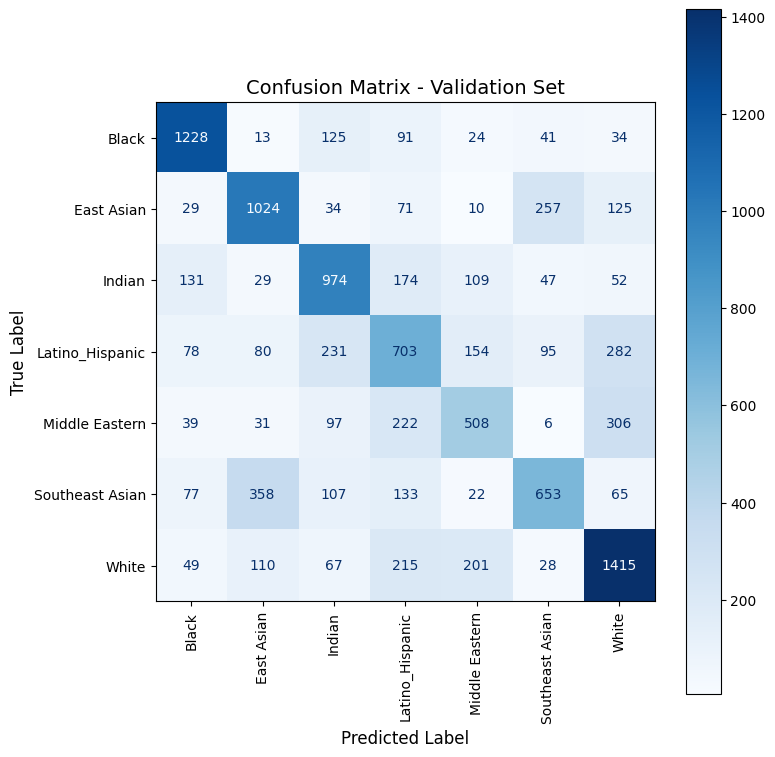

In [30]:
import torch
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

checkpoint = torch.load('best_model.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()

all_preds = []
all_labels = []

print("در حال ارزیابی مدل روی داده‌های Validation...")

with torch.no_grad():
    for images, labels in val_dataloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

class_names = val_dataset.classes
print("\n--- Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical', values_format='d', ax=plt.gca())
plt.title("Confusion Matrix - Validation Set", fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.tight_layout()
plt.show()